# 04_customer_segmentation_kmeans Yet to start

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
rfm = pd.read_csv('../data/processed/rfm_data.csv')
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,Segment
0,12346,326,1,77183.60,1,1,5,Lost
1,12347,2,7,4310.00,5,5,5,Champions
2,12348,75,4,1437.24,2,4,4,Loyal Customers
3,12349,19,1,1457.55,4,1,4,Lost
4,12350,310,1,294.40,1,1,2,Lost


### Create DF for RFM

In [3]:
rfm_ml = rfm[['Recency', 'Frequency', 'Monetary']]
rfm_ml.head()

,Recency,Frequency,Monetary
0,326,1,77183.60
1,2,7,4310.00
2,75,4,1437.24
3,19,1,1457.55
4,310,1,294.40


In [4]:
rfm_ml.describe()

,Recency,Frequency,Monetary
count,4334.000000,4334.000000,4334.000000
mean,92.703046,4.245962,2015.973152
std,100.177047,7.634989,8903.673825
min,1.000000,1.000000,3.750000
25%,18.000000,1.000000,304.240000
50%,51.000000,2.000000,662.565000
75%,143.000000,5.000000,1631.622500
max,374.000000,206.000000,279138.020000


**Data is not Normalised.**

In [5]:
# Log1p transform for reduce skewness
rfm_log = np.log1p(rfm_ml)
rfm_log.head()

,Recency,Frequency,Monetary
0,5.789960,0.693147,11.253955
1,1.098612,2.079442,8.368925
2,4.330733,1.609438,7.271175
3,2.995732,0.693147,7.285198
4,5.739793,0.693147,5.688330


### Clustering.py 

In [6]:
import sys
sys.path.append('../src')
from clustering import scale_features,apply_kmeans,sil_score

In [7]:
rfm_scaled = scale_features(rfm_log) # Refer clustering.py for scale_feature

rfm_scaled[:5]

array([[ 1.46043793, -0.95128044,  3.72823778],
       [-2.03895624,  1.08229127,  1.42917405],
       [ 0.371964  ,  0.39283735,  0.55438363],
       [-0.62384682, -0.95128044,  0.5655582 ],
       [ 1.42301691, -0.95128044, -0.70697642]])

In [8]:
inertia = []
for k in range(1, 11):
    model,labels = apply_kmeans(rfm_scaled,k) # Refer clustering.py for apply_kmeans
    inertia.append(model.inertia_)

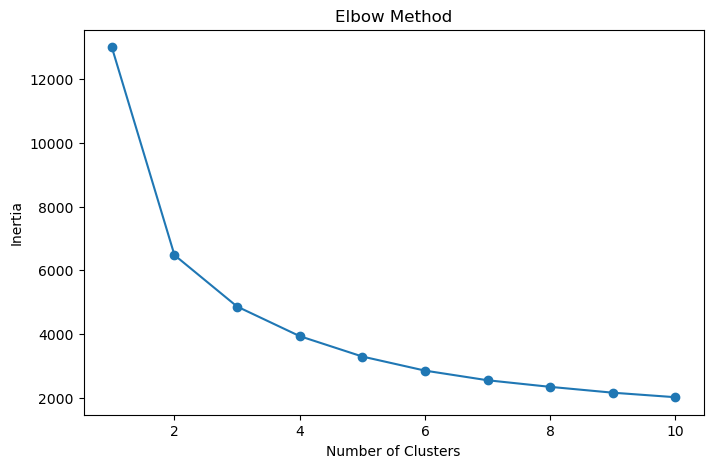

In [9]:
# Visualise elbow bow 
plt.figure(figsize=(8,5))
plt.plot(range(1,11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

***From the ELBOW method, Optimal number of cluster 3 or 4. So we choose 4.***

In [10]:
model, rfm['Cluster'] = apply_kmeans(rfm_scaled,4)

In [11]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,Segment,Cluster
0,12346,326,1,77183.60,1,1,5,Lost,2
1,12347,2,7,4310.00,5,5,5,Champions,3
2,12348,75,4,1437.24,2,4,4,Loyal Customers,2
3,12349,19,1,1457.55,4,1,4,Lost,0
4,12350,310,1,294.40,1,1,2,Lost,1


In [12]:
rfm.groupby('Cluster')[['Recency','Frequency','Monetary']].mean()

,Recency,Frequency,Monetary
Cluster,,,
0,18.564804,2.102259,531.499180
1,183.189602,1.332110,350.697180
2,67.043515,4.175768,1805.264480
3,11.766764,13.938776,8164.835233


In [13]:
cluster_names = {
    0: "Regular",
    1: "At_Risk",
    2: "High_Value",
    3: "Champions"
}

rfm['Segment'] = rfm['Cluster'].map(cluster_names)

In [14]:
rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_score,F_score,M_score,Segment,Cluster
0,12346,326,1,77183.60,1,1,5,High_Value,2
1,12347,2,7,4310.00,5,5,5,Champions,3
2,12348,75,4,1437.24,2,4,4,High_Value,2
3,12349,19,1,1457.55,4,1,4,Regular,0
4,12350,310,1,294.40,1,1,2,At_Risk,1


In [15]:
from sklearn.metrics import silhouette_score

score = silhouette_score(rfm_scaled, rfm['Cluster'])
print("Silhouette Score:", score)

Silhouette Score: 0.33772813789124323


In [16]:
for k in range(2,8):
    sil_score(rfm_scaled,k)

K=2, Silhouette Score=0.43300258879873554
K=3, Silhouette Score=0.3371861350302716
K=4, Silhouette Score=0.33772813789124323
K=5, Silhouette Score=0.3174730075343568
K=6, Silhouette Score=0.31412251366926985
K=7, Silhouette Score=0.3100746475907192


**K=4 is optimal**

**Although traditional RFM scoring can create 6+ segments, our data-driven analysis showed 4 clusters provide better separation and clearer business interpretation.**

### Visualization

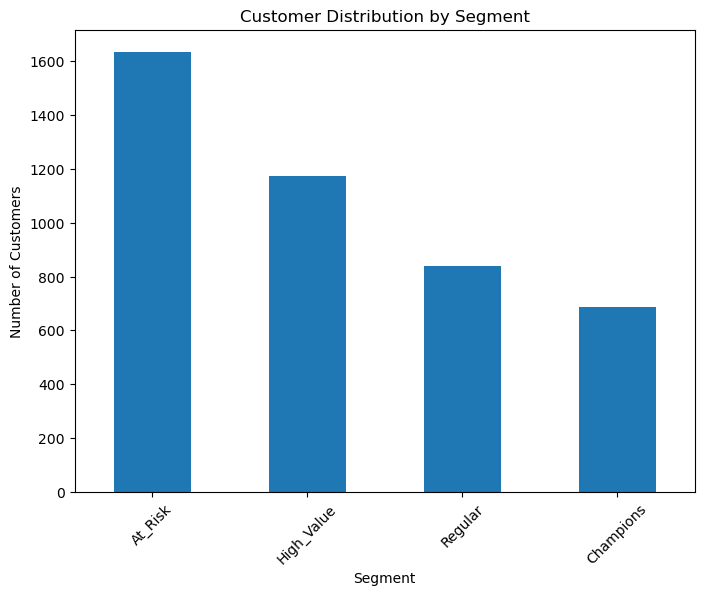

In [25]:
plt.figure(figsize=(8,6))
rfm['Segment'].value_counts().plot(kind='bar')
plt.title('Customer Distribution by Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45)
#Saving plot in results folder
plt.savefig("../results/customer_distribution_segment.png", bbox_inches="tight")
plt.show()

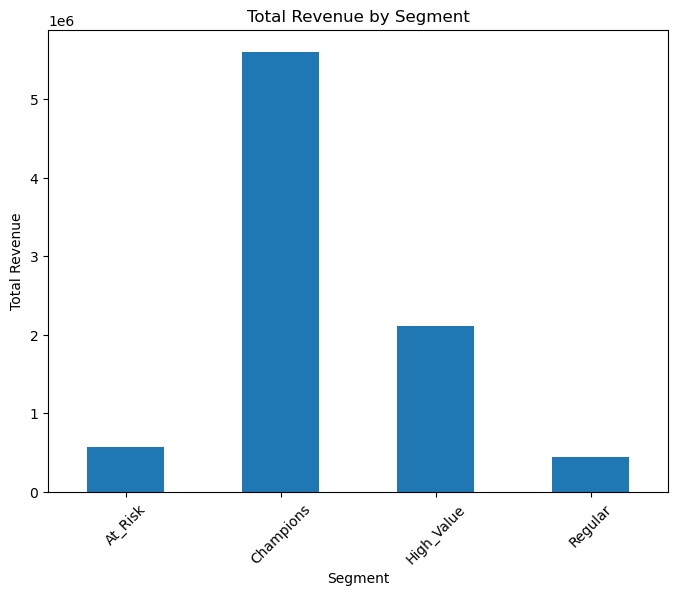

In [29]:
plt.figure(figsize=(8,6))
rfm.groupby('Segment')['Monetary'].sum().plot(kind='bar')
plt.title('Total Revenue by Segment')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45)
#Saving plot in results folder
plt.savefig("../results/revenue_by_segment.png", bbox_inches="tight")
plt.show()

# END